# KevinH1–H3 — pair-level structure–function baseline (906 cohort)

**Owner:** Kevin (Person 1).
**Scope:** Hypotheses 1–3 of the team scaffold in `REAL final structure.ipynb`.

Hypotheses tested in this notebook:

- **H1.** Connected pairs have higher `F_corr` than unconnected pairs.
- **H2.** Among connected pairs, larger summed synaptic strength predicts higher `F_corr`.
- **H3.** Reciprocity premium: `bi > uni > none` in mean `F_corr`.

Conventions (kept identical to the rest of the team):

- Cohort: **906** proofread / functionally matched MICrONS neurons (`Data/cache/matched_906.pkl`, `Data/cache/F_906.npy`).
- Functional metric: **Pearson signal correlation** across oracle-stimulus columns of `F_906.npy`. This is *signal* correlation, **not** noise correlation.
- Structural matrix: directed `C[pre, post]`, weight = **summed synapse size / cleft volume** (NOT synapse counts).
- Pair labels for `i<j` unordered pairs: `none`, `uni`, `bi`.

Each hypothesis is tested twice. The naive Mann–Whitney / Spearman tests in §5–§7 treat all pairs as i.i.d., which they are not (every neuron sits in N − 1 pairs). The **neuron-identity permutation nulls** in §5b / §6b / §7b respect that pair-sharing dependence and produce the p-values that should be quoted in the report; the §7b cell additionally re-runs `bi > uni` on V1-V1 pairs only to remove the area-composition bias between the `bi` and `uni` pools.

Outputs produced when the notebook runs end-to-end:

- `outputs/figures/person1_h1_h3_pair_baseline.png` — 4-panel summary figure (A: H1 violins; B: H2 strength scatter; C: H2 quartile means; D: H3 group means).
- `outputs/tables/person1_h1_h3_summary.csv` — compact result table for the team-combined notebook, including permutation-null fields for H1/H2/H3 and V1-V1-stratified fields for H3.

## 0. Setup

Imports, repo paths, plotting style, and a fixed RNG seed for the bootstraps.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import sparse
from scipy.stats import mannwhitneyu, spearmanr, pearsonr
import matplotlib.pyplot as plt

# ---- repo-root paths (run from the project root) ----
ROOT = Path.cwd()
for _ in range(5):
    if (ROOT / 'data' / 'cache').exists() or (ROOT / 'Data' / 'cache').exists():
        break
    ROOT = ROOT.parent

DATA = ROOT / 'data' if (ROOT / 'data').exists() else ROOT / 'Data'
CACHE_DIR   = DATA / 'cache'
EXPORTS_DIR = DATA / 'exports'
FIG_DIR = ROOT / 'outputs' / 'figures'
TBL_DIR = ROOT / 'outputs' / 'tables'
FIG_DIR.mkdir(parents=True, exist_ok=True)
TBL_DIR.mkdir(parents=True, exist_ok=True)

print('ROOT     =', ROOT)
print('DATA     =', DATA)
print('CACHE    =', CACHE_DIR, '(exists:', CACHE_DIR.exists(), ')')
print('EXPORTS  =', EXPORTS_DIR, '(exists:', EXPORTS_DIR.exists(), ')')

# ---- plotting style ----
plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 160,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})
PAL_CONN   = {'none': '#bdbdbd', 'uni': '#4c78a8', 'bi': '#e45756'}
ORDER_CONN = ['none', 'uni', 'bi']
RNG_SEED   = 0

ROOT     = c:\Users\shaqi\Desktop\NeuroFinalProject
DATA     = c:\Users\shaqi\Desktop\NeuroFinalProject\data
CACHE    = c:\Users\shaqi\Desktop\NeuroFinalProject\data\cache (exists: True )
EXPORTS  = c:\Users\shaqi\Desktop\NeuroFinalProject\data\exports (exists: True )


## 1. Load the 906 cohort

`matched_906.pkl` defines the canonical neuron ordering used to build `F_906.npy`. The structural-edge file `G_906_edges.csv` carries one row per directed `(pre → post)` pair with the **summed synapse size (cleft volume)** as the weight.

In [2]:
matched = pd.read_pickle(CACHE_DIR / 'matched_906.pkl')
if 'matrix_index' in matched.columns:
    matched = matched.sort_values('matrix_index', kind='stable').reset_index(drop=True)

N = len(matched)
print(f'matched neurons : {N}')
print('columns         :', list(matched.columns))

# pt_root_id is used as the lookup key from edges -> matrix index, so it must be unique
assert matched['pt_root_id'].is_unique, \
    'pt_root_id must be unique within the 906 cohort (otherwise edge lookup is ambiguous)'

F = np.load(CACHE_DIR / 'F_906.npy')
print(f'F_906 shape     : {F.shape}   (neurons x oracle conditions)')
assert F.shape[0] == N, 'F_906 row count must equal the matched cohort size'

edges = pd.read_csv(EXPORTS_DIR / 'G_906_edges.csv')
print(f'edges rows      : {len(edges):,}')

# ---- validate the structural-weight column is plausibly cleft volume, not a count ----
ssz = edges['synapse_size']
n_dup_pairs = edges.duplicated(subset=['pre_neuron_id', 'post_neuron_id']).sum()
print()
print('--- structural-weight sanity ---')
print(f'duplicate (pre,post) rows  : {n_dup_pairs}   (0 -> already aggregated per directed edge)')
print(f'synapse_size: min={ssz.min():.0f}  median={ssz.median():.0f}  '
      f'mean={ssz.mean():.0f}  max={ssz.max():.0f}')
# A synapse-COUNT column would have integer values with a max in the low tens.
# A cleft-VOLUME column is heavy-tailed with a max in the thousands+.
assert ssz.min() >= 0 and ssz.max() > 100, \
    'synapse_size has implausibly small max for a cleft volume - looks like a count column'
print('-> synapse_size is consistent with summed cleft volume (NOT a synapse count).')
edges.head(3)

matched neurons : 906
columns         : ['nucleus_id', 'pt_root_id', 'pt_position_x', 'pt_position_y', 'pt_position_z', 'classification_system', 'cell_type', 'brain_area', 'strategy_axon', 'strategy_dendrite', 'session', 'scan_idx', 'unit_id', 'pref_ori', 'pref_dir', 'gOSI', 'gDSI', 'cc_abs', 'tuning_type', 'layer']
F_906 shape     : (906, 116)   (neurons x oracle conditions)
edges rows      : 11,822

--- structural-weight sanity ---
duplicate (pre,post) rows  : 0   (0 -> already aggregated per directed edge)
synapse_size: min=160  median=5170  mean=9305  max=308136
-> synapse_size is consistent with summed cleft volume (NOT a synapse count).


,pre_neuron_id,post_neuron_id,synapse_size
0,864691135763941174,864691135619756943,5044.0
1,864691135763941174,864691135750307881,11860.0
2,864691135763941174,864691135927494158,1764.0


## 2. Build the structural matrix `C[pre, post]`

Rows are presynaptic neurons, columns are postsynaptic neurons. The edge weight is the total synapse cleft volume from `i → j`. We:

- restrict edges to neurons in the 906 cohort,
- drop autapses,
- collapse any duplicate `(pre, post)` rows by summing their `synapse_size` (handled automatically by `coo → csr`).

In [3]:
pt_to_idx = pd.Series(np.arange(N), index=matched['pt_root_id'].astype('int64'))

pre_id  = edges['pre_neuron_id'].astype('int64')
post_id = edges['post_neuron_id'].astype('int64')
valid_edge = pre_id.isin(pt_to_idx.index) & post_id.isin(pt_to_idx.index) & (pre_id != post_id)
edges_in = edges.loc[valid_edge].copy()

rows = pt_to_idx.loc[edges_in['pre_neuron_id'].astype('int64')].to_numpy()
cols = pt_to_idx.loc[edges_in['post_neuron_id'].astype('int64')].to_numpy()
data = edges_in['synapse_size'].to_numpy(dtype=np.float64)

C = sparse.coo_matrix((data, (rows, cols)), shape=(N, N)).tocsr()
C.setdiag(0)
C.eliminate_zeros()

print(f'C: shape={C.shape}, nnz={C.nnz:,}, directed density = {C.nnz/(N*N):.3e}')
print(f'mean edge weight (cleft volume) : {C.data.mean():.1f}')
print(f'edges dropped (out-of-cohort or autapse): {len(edges) - len(edges_in):,}')

C: shape=(906, 906), nnz=11,822, directed density = 1.440e-02
mean edge weight (cleft volume) : 9304.7
edges dropped (out-of-cohort or autapse): 0


## 3. Functional similarity matrix `F_corr`

Pearson correlation across oracle-stimulus columns. The diagonal is forced to 1. Rows of `F` whose responses are constant or contain NaN propagate NaN into `F_corr`; we drop those pairs when building the pair table below.

In [4]:
F_corr = np.corrcoef(F)
# np.corrcoef already places 1.0 on the diagonal; no manual fill needed.

off    = ~np.eye(N, dtype=bool)
finite = np.isfinite(F_corr) & off
n_offdiag = int(off.sum())
n_finite  = int(finite.sum())

print(f'F_corr shape : {F_corr.shape}')
print(f'off-diagonal entries            : {n_offdiag:,}')
print(f'finite off-diagonal entries     : {n_finite:,}')
if n_finite == n_offdiag:
    print('  -> F_corr is FULLY FINITE on this cohort; the downstream `finite_pair`')
    print('     mask in section 4 is a guard for cohort changes, not active filtering.')
else:
    print(f'  -> {n_offdiag - n_finite} non-finite entries; the section-4 mask will drop those pairs.')
print(f'mean F_corr (finite off-diag)   : {F_corr[finite].mean():+.4f}')
print(f'median F_corr (finite off-diag) : {np.median(F_corr[finite]):+.4f}')

F_corr shape : (906, 906)
off-diagonal entries            : 819,930
finite off-diagonal entries     : 819,930
  -> F_corr is FULLY FINITE on this cohort; the downstream `finite_pair`
     mask in section 4 is a guard for cohort changes, not active filtering.
mean F_corr (finite off-diag)   : +0.0232
median F_corr (finite off-diag) : +0.0103


## 4. Build the pair table

One row per **unordered** pair `i < j`. Each row carries `syn_ij` and `syn_ji` from the directed `C`, from which we derive:

- `connected` — true if either direction has a synapse,
- `conn_type` — `bi` (both directions present), `uni` (exactly one direction), `none`,
- `syn_size_max` — `max(C[i,j], C[j,i])`; 0 for unconnected pairs,
- `syn_size_sum` — `C[i,j] + C[j,i]`; 0 for unconnected pairs.

Pairs whose `f_corr` is NaN (because at least one neuron has an invalid functional row) are dropped before any test.

In [5]:
C_dense = C.toarray()                            # (906, 906) — fine at this N
A_pre   = C_dense > 0                            # i → j
A_post  = C_dense.T > 0                          # j → i
A_und   = A_pre | A_post
np.fill_diagonal(A_und, False)
bidir   = A_pre & A_post

iu, ju = np.triu_indices(N, k=1)
finite_pair = np.isfinite(F_corr[iu, ju])
iu, ju = iu[finite_pair], ju[finite_pair]

syn_ij = C_dense[iu, ju]
syn_ji = C_dense[ju, iu]
pairs = pd.DataFrame({
    'i': iu, 'j': ju,
    'f_corr': F_corr[iu, ju],
    'syn_ij': syn_ij,
    'syn_ji': syn_ji,
})
pairs['syn_size_max'] = np.maximum(pairs['syn_ij'], pairs['syn_ji'])
pairs['syn_size_sum'] = pairs['syn_ij'] + pairs['syn_ji']
pairs['connected']    = pairs['syn_size_max'] > 0
pairs['conn_type']    = np.where(
    bidir[iu, ju], 'bi',
    np.where(A_und[iu, ju], 'uni', 'none'),
)

n_total_possible = N * (N - 1) // 2
print(f'unordered pairs (max possible) : {n_total_possible:,}')
print(f'pairs with finite f_corr       : {len(pairs):,}')
print('conn_type counts               :', pairs['conn_type'].value_counts().to_dict())
print()
print('mean f_corr by group:')
print(pairs.groupby('conn_type')['f_corr'].agg(['count', 'mean', 'std']).reindex(ORDER_CONN))

unordered pairs (max possible) : 409,965
pairs with finite f_corr       : 409,965
conn_type counts               : {'none': 398385, 'uni': 11338, 'bi': 242}

mean f_corr by group:
            count      mean       std
conn_type                            
none       398385  0.022256  0.137008
uni         11338  0.055432  0.143400
bi            242  0.067990  0.166750


## 5. H1 — connected pairs have higher `F_corr` than unconnected pairs

**Statistic.** One-sided Mann–Whitney U with alternative `connected > unconnected`. Effect size: Cohen's *d*. Uncertainty on the mean difference: 95% percentile bootstrap with 5,000 paired resamples.

A directional alternative is appropriate because the literature (e.g. MICrONS Consortium 2025) predicts a *positive* like-to-like wiring rule; we are not testing for a two-sided difference.

In [6]:
def boot_mean_diff(a, b, n_boot=5000, seed=RNG_SEED):
    rng = np.random.default_rng(seed)
    diffs = np.empty(n_boot)
    na, nb = len(a), len(b)
    for k in range(n_boot):
        diffs[k] = rng.choice(a, na, replace=True).mean() - rng.choice(b, nb, replace=True).mean()
    return diffs.mean(), np.percentile(diffs, [2.5, 97.5])

def cohens_d(a, b):
    na, nb = len(a), len(b)
    sp = np.sqrt(((na - 1) * a.var(ddof=1) + (nb - 1) * b.var(ddof=1)) / (na + nb - 2))
    return (a.mean() - b.mean()) / sp

f_none = pairs.loc[pairs.conn_type == 'none', 'f_corr'].to_numpy()
f_uni  = pairs.loc[pairs.conn_type == 'uni',  'f_corr'].to_numpy()
f_bi   = pairs.loc[pairs.conn_type == 'bi',   'f_corr'].to_numpy()
f_conn = pairs.loc[pairs.connected,           'f_corr'].to_numpy()

U_h1, p_h1     = mannwhitneyu(f_conn, f_none, alternative='greater')
md_h1, ci_h1   = boot_mean_diff(f_conn, f_none)
d_h1           = cohens_d(f_conn, f_none)
median_diff_h1 = float(np.median(f_conn) - np.median(f_none))

print(f'H1 - connected (n={len(f_conn):,}) vs unconnected (n={len(f_none):,})')
print(f'  delta-mean   (conn - none) = {md_h1:+.4f}    95% CI [{ci_h1[0]:+.4f}, {ci_h1[1]:+.4f}]')
print(f'  delta-median (conn - none) = {median_diff_h1:+.4f}')
print(f'  Mann-Whitney U             = {U_h1:.3e}    one-sided p = {p_h1:.3e}')
print(f"  Cohen's d                  = {d_h1:+.3f}    (small effect by Cohen's conventions)")
print('  NOTE: the MW p-value treats pairs as independent, which they are not;')
print('        a neuron-level permutation null is computed in the next section.')

H1_RESULT = {
    'hypothesis':     'H1',
    'description':    'connected > unconnected (signal F_corr)',
    'test_direction': 'one-sided (connected > unconnected)',
    'n_connected':    int(len(f_conn)),
    'n_unconnected':  int(len(f_none)),
    'mean_diff':      float(md_h1),
    'median_diff':    median_diff_h1,
    'ci_lo':          float(ci_h1[0]),
    'ci_hi':          float(ci_h1[1]),
    'cohens_d':       float(d_h1),
    'mannwhitney_U':  float(U_h1),
    'p_one_sided':    float(p_h1),
}

H1 - connected (n=11,580) vs unconnected (n=398,385)
  delta-mean   (conn - none) = +0.0335    95% CI [+0.0309, +0.0361]
  delta-median (conn - none) = +0.0326
  Mann-Whitney U             = 2.614e+09    one-sided p = 4.758e-133
  Cohen's d                  = +0.244    (small effect by Cohen's conventions)
  NOTE: the MW p-value treats pairs as independent, which they are not;
        a neuron-level permutation null is computed in the next section.


### 5b. H1 — neuron-level permutation null (handles pair non-independence)

The Mann–Whitney U above treats 409,965 pairs as independent observations, which they are not — every neuron sits in N − 1 pairs, so pair rows are heavily dependent. The astronomical p-value reflects that violated assumption as much as the underlying effect (this is exactly the caveat flagged in §15.9 of the team scaffold).

To get an honest p-value we run a **neuron-identity permutation**: the structural graph and the functional correlation matrix are held fixed, and we permute neuron labels π ∈ S_N before re-reading each pair's structural status. This null preserves (i) the functional correlation matrix, (ii) the structural degree distribution, and (iii) the pair-sharing dependence — i.e. it respects the actual unit of randomization. We then ask how often a random relabeling produces a Δmean(conn − none) at least as large as the observed value.

In [7]:
# ---- neuron-identity permutation null for H1 ----
# The structural undirected adjacency A_und (computed in section 4) is held fixed.
# For each permutation pi we re-read each pair's connection status as A_und[pi[i], pi[j]],
# recompute Delta-mean(conn - none) using the original f_corr values, and tally how
# often that exceeds the observed Delta-mean.

iu_all, ju_all = np.triu_indices(N, k=1)
fmask = np.isfinite(F_corr[iu_all, ju_all])
iu_all = iu_all[fmask]
ju_all = ju_all[fmask]
f_pairs_arr = F_corr[iu_all, ju_all]

# A_und was implicitly built in section 4; reconstruct it here so this cell is self-contained
A_und = (C_dense > 0) | (C_dense.T > 0)
np.fill_diagonal(A_und, False)

obs_diff = float(f_conn.mean() - f_none.mean())

N_PERM = 10000
rng = np.random.default_rng(RNG_SEED)
perm_diffs = np.empty(N_PERM)
for k in range(N_PERM):
    pi = rng.permutation(N)
    conn_k = A_und[pi[iu_all], pi[ju_all]]
    perm_diffs[k] = f_pairs_arr[conn_k].mean() - f_pairs_arr[~conn_k].mean()

n_exceed = int((perm_diffs >= obs_diff).sum())
p_perm   = (n_exceed + 1) / (N_PERM + 1)   # one-sided, with the standard +1/+1 correction
null_mu  = float(perm_diffs.mean())
null_sd  = float(perm_diffs.std(ddof=1))
null_lo, null_hi = np.percentile(perm_diffs, [2.5, 97.5])
z_obs = (obs_diff - null_mu) / null_sd if null_sd > 0 else float('inf')

print(f'H1 neuron-identity permutation null (n_perm = {N_PERM:,})')
print(f'  observed delta-mean    = {obs_diff:+.4f}')
print(f'  null mean +/- std      = {null_mu:+.4f} +/- {null_sd:.4f}')
print(f'  null 95% range         = [{null_lo:+.4f}, {null_hi:+.4f}]')
print(f'  observed sits at z     = {z_obs:+.2f}  std deviations from null mean')
print(f'  one-sided perm p-value = {p_perm:.4e}   (#perms >= observed: {n_exceed}/{N_PERM})')

H1_RESULT['perm_n']             = int(N_PERM)
H1_RESULT['perm_null_mean']     = null_mu
H1_RESULT['perm_null_std']      = null_sd
H1_RESULT['perm_z']             = float(z_obs)
H1_RESULT['perm_p_one_sided']   = float(p_perm)

H1 neuron-identity permutation null (n_perm = 10,000)
  observed delta-mean    = +0.0334
  null mean +/- std      = +0.0000 +/- 0.0016
  null 95% range         = [-0.0032, +0.0033]
  observed sits at z     = +20.42  std deviations from null mean
  one-sided perm p-value = 9.9990e-05   (#perms >= observed: 0/10000)


## 6. H2 — synapse-strength gradient (connected pairs only)

Among connected pairs, do larger summed synaptic strengths predict higher `F_corr`?

Primary statistic: **Spearman ρ** on `(syn_size_sum, f_corr)`, because synapse-size is heavy-tailed. Secondary check: Pearson on `log10(syn_size_sum)` to confirm the direction. We also bin connected pairs into strength quartiles and compare mean `f_corr` ± SEM.

In [8]:
def boot_spearman_ci(x, y, n_boot=2000, seed=RNG_SEED):
    """95% percentile bootstrap CI for Spearman rho. Pairs (x, y) are resampled
    jointly so the rank-relation within each resample is preserved."""
    rng = np.random.default_rng(seed)
    n = len(x)
    x = np.asarray(x); y = np.asarray(y)
    rhos = np.empty(n_boot)
    for k in range(n_boot):
        idx = rng.integers(0, n, n)
        rhos[k] = spearmanr(x[idx], y[idx]).statistic
    return float(np.percentile(rhos, 2.5)), float(np.percentile(rhos, 97.5))

conn = pairs.loc[pairs.connected].copy()
# Spearman is rank-invariant, so no transform of `syn_size_sum` is needed for the
# primary statistic. log10(...) is computed only for the Pearson sensitivity check
# and for plotting, since `syn_size_sum` is heavy-tailed (max ~ 6e5).
conn['log10_size_sum'] = np.log10(conn['syn_size_sum'].clip(lower=1.0))
conn['log10_size_max'] = np.log10(conn['syn_size_max'].clip(lower=1.0))

rho_h2,    p_rho_h2    = spearmanr(conn['syn_size_sum'], conn['f_corr'])
rho_max,   p_rho_max   = spearmanr(conn['syn_size_max'], conn['f_corr'])
r_pearson, p_pearson   = pearsonr(conn['log10_size_sum'], conn['f_corr'])
ci_lo_h2,  ci_hi_h2    = boot_spearman_ci(conn['syn_size_sum'].to_numpy(),
                                          conn['f_corr'].to_numpy())
r2_log = float(r_pearson ** 2)

print(f'H2 - connected pairs only (n={len(conn):,})')
print(f'  Spearman rho (syn_size_sum, f_corr)   = {rho_h2:+.4f}    '
      f'95% boot CI [{ci_lo_h2:+.4f}, {ci_hi_h2:+.4f}]    p = {p_rho_h2:.2e}    (primary, two-sided)')
print(f'  Spearman rho (syn_size_max, f_corr)   = {rho_max:+.4f}    p = {p_rho_max:.2e}    (sensitivity check)')
print(f'  Pearson  r   (log10 size_sum, f_corr) = {r_pearson:+.4f}    p = {p_pearson:.2e}')
print(f'  Pearson  r^2 on log10 strength        = {r2_log:.4f}    '
      f'(<1% of F_corr variance is *linearly* explained by log strength)')
print('  NOTE: Spearman rho^2 is NOT a fraction of variance explained;')
print('        we report the Pearson r^2 on log10 strength as the proper variance-explained scale.')

conn['quartile'] = pd.qcut(conn['syn_size_sum'], 4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
q = conn.groupby('quartile', observed=True)['f_corr'].agg(['count', 'mean', 'sem'])
print()
print('quartile means of F_corr (Q1 = weakest, Q4 = strongest):')
print(q)

H2_RESULT = {
    'hypothesis':         'H2',
    'description':        'syn_size_sum vs F_corr (connected only)',
    'test_direction':     'two-sided Spearman',
    'n_connected':        int(len(conn)),
    'spearman_rho_sum':   float(rho_h2),
    'spearman_ci_lo':     float(ci_lo_h2),
    'spearman_ci_hi':     float(ci_hi_h2),
    'p_spearman_sum':     float(p_rho_h2),
    'spearman_rho_max':   float(rho_max),
    'p_spearman_max':     float(p_rho_max),
    'pearson_log10_r':    float(r_pearson),
    'pearson_log10_r2':   r2_log,
    'p_pearson_log10':    float(p_pearson),
}

H2 - connected pairs only (n=11,580)
  Spearman rho (syn_size_sum, f_corr)   = +0.0686    95% boot CI [+0.0498, +0.0861]    p = 1.44e-13    (primary, two-sided)
  Spearman rho (syn_size_max, f_corr)   = +0.0690    p = 1.09e-13    (sensitivity check)
  Pearson  r   (log10 size_sum, f_corr) = +0.0695    p = 6.77e-14
  Pearson  r^2 on log10 strength        = 0.0048    (<1% of F_corr variance is *linearly* explained by log strength)
  NOTE: Spearman rho^2 is NOT a fraction of variance explained;
        we report the Pearson r^2 on log10 strength as the proper variance-explained scale.

quartile means of F_corr (Q1 = weakest, Q4 = strongest):
          count      mean       sem
quartile                           
Q1         2895  0.044211  0.002594
Q2         2895  0.052571  0.002657
Q3         2895  0.054816  0.002676
Q4         2895  0.071179  0.002748


### 6b. H2 — neuron-level permutation null

The Spearman p in §6 inherits the same pair-non-independence problem as H1: every neuron sits in many connected pairs, so the rank-correlation test treats heavily dependent observations as i.i.d. Same fix as §5b: hold `F_corr` and the structural graph `C` fixed, permute neuron labels π, re-derive the set of `connected` pairs from `C` under the relabeling, and recompute Spearman ρ(`syn_size_sum`, `f_corr`) on those pairs.

This null preserves (i) the `F_corr` matrix, (ii) the marginal distribution of `syn_size_sum`, and (iii) the structural degree distribution — only the structure-function alignment is randomized. Two-sided test, since H2 predicts a non-zero gradient but the null could in principle deviate either way.

In [9]:
# ---- neuron-identity permutation null for H2 ----
# For each permutation pi:
#   - syn_ij_perm = C[pi[i], pi[j]],  syn_ji_perm = C[pi[j], pi[i]]
#   - syn_sum_perm = syn_ij_perm + syn_ji_perm
#   - 'connected' pairs are those with syn_sum_perm > 0
#   - Spearman rho is recomputed on (syn_sum_perm, f_corr) over those pairs.
# F_corr and C are both fixed; only neuron labels move. Two-sided test.

N_PERM_H2 = 5000
rng = np.random.default_rng(RNG_SEED + 1)
obs_rho_h2 = float(rho_h2)
perm_rhos_h2 = np.empty(N_PERM_H2)
for k in range(N_PERM_H2):
    pi = rng.permutation(N)
    s_ij = C_dense[pi[iu_all], pi[ju_all]]
    s_ji = C_dense[pi[ju_all], pi[iu_all]]
    s_sum = s_ij + s_ji
    conn_k = s_sum > 0
    if conn_k.sum() < 5:
        perm_rhos_h2[k] = 0.0
        continue
    perm_rhos_h2[k] = spearmanr(s_sum[conn_k], f_pairs_arr[conn_k]).statistic

n_exceed_h2 = int((np.abs(perm_rhos_h2) >= abs(obs_rho_h2)).sum())
p_perm_h2 = (n_exceed_h2 + 1) / (N_PERM_H2 + 1)
null_mu_h2 = float(perm_rhos_h2.mean())
null_sd_h2 = float(perm_rhos_h2.std(ddof=1))
z_obs_h2 = (obs_rho_h2 - null_mu_h2) / null_sd_h2 if null_sd_h2 > 0 else float('inf')

print(f'H2 neuron-identity permutation null (n_perm = {N_PERM_H2:,})')
print(f'  observed Spearman rho   = {obs_rho_h2:+.4f}')
print(f'  null mean +/- std       = {null_mu_h2:+.4f} +/- {null_sd_h2:.4f}')
print(f'  observed sits at z      = {z_obs_h2:+.2f}  std deviations from null mean')
print(f'  two-sided perm p-value  = {p_perm_h2:.4e}   (#perms |rho| >= |obs|: {n_exceed_h2}/{N_PERM_H2})')

H2_RESULT['perm_n']           = int(N_PERM_H2)
H2_RESULT['perm_null_mean']   = null_mu_h2
H2_RESULT['perm_null_std']    = null_sd_h2
H2_RESULT['perm_z']           = float(z_obs_h2)
H2_RESULT['perm_p_two_sided'] = float(p_perm_h2)

H2 neuron-identity permutation null (n_perm = 5,000)
  observed Spearman rho   = +0.0686
  null mean +/- std       = +0.0000 +/- 0.0095
  observed sits at z      = +7.21  std deviations from null mean
  two-sided perm p-value  = 1.9996e-04   (#perms |rho| >= |obs|: 0/5000)


## 7. H3 — reciprocity premium (`bi > uni > none`)

Bootstrap 95% CI on the mean of each group, plus pairwise one-sided Mann–Whitney tests for `bi > none`, `bi > uni`, and `uni > none`.

**Power-aware caveat for `bi > uni`.** `n_bi = 242` looks small next to `n_uni`, but it is *not* the limiting factor in the way it might first appear. With this sample the design has good power for an effect the size of `uni − none` (Cohen's *d* ≈ 0.24); if `bi − uni` were that large we would detect it. What it has only **modest power for is the *observed* `bi − uni` gap** (*d* ≈ 0.09 — printed below). The right reading of a non-significant `bi > uni` is therefore *"the data exclude a `bi − uni` effect as large as the `uni − none` step, but cannot rule out a small positive one"* — not "we lack the data to test it."

We also break down the 242 `bi` pairs and the 11,338 `uni` pairs by area composition. If `bi` pairs were systematically more cross-area (or more V1-V1) than `uni` pairs, the near-tie could in principle be geographic rather than a true reciprocity ceiling.

In [10]:
def boot_mean_ci(x, n_boot=4000, seed=RNG_SEED):
    rng = np.random.default_rng(seed)
    bm = np.array([rng.choice(x, len(x), replace=True).mean() for _ in range(n_boot)])
    return float(x.mean()), float(np.percentile(bm, 2.5)), float(np.percentile(bm, 97.5))

groups = {'none': f_none, 'uni': f_uni, 'bi': f_bi}
group_stats = {}
for g in ORDER_CONN:
    m_, lo_, hi_ = boot_mean_ci(groups[g])
    group_stats[g] = {'n': int(len(groups[g])), 'mean': m_, 'ci_lo': lo_, 'ci_hi': hi_}
    print(f'{g:>4s}  n={len(groups[g]):>7,d}   mean f_corr = {m_:+.4f}   95% CI [{lo_:+.4f}, {hi_:+.4f}]')

pairwise = []
for name, a, b in [('bi > none', f_bi, f_none),
                   ('bi > uni',  f_bi, f_uni),
                   ('uni > none', f_uni, f_none)]:
    U_, p_ = mannwhitneyu(a, b, alternative='greater')
    pairwise.append((name, U_, p_))
    print(f'  {name:>11s}   U = {U_:.3e}   one-sided p = {p_:.3e}')

# ---- Power-aware framing of the bi > uni non-significance ----
# Cohen's d for the observed bi-uni gap, and for the uni-none gap as a reference.
def _pooled_d(a, b):
    na, nb = len(a), len(b)
    sp = np.sqrt(((na - 1) * a.var(ddof=1) + (nb - 1) * b.var(ddof=1)) / (na + nb - 2))
    return float((a.mean() - b.mean()) / sp)

d_uni_none = _pooled_d(f_uni, f_none)
d_bi_uni   = _pooled_d(f_bi,  f_uni)
print()
print(f"  Cohen's d (uni - none) = {d_uni_none:+.3f}    (the 'uni > none' effect)")
print(f"  Cohen's d (bi  - uni)  = {d_bi_uni:+.3f}    (the actual 'bi > uni' gap; small)")
print( '  Reading: with n_bi = 242, the design has good power for d = 0.24,')
print( '          but only modest power for d ~ 0.09. The data therefore *exclude*')
print( '          a bi - uni gap as large as the uni - none step, while not ruling')
print( '          out a small positive bi - uni effect.')

# ---- Area composition of bi vs uni pairs (is the near-tie geographic?) ----
ba = matched['brain_area'].astype(str).to_numpy()
def area_breakdown(idx_pairs):
    a = ba[idx_pairs[:, 0]]; b = ba[idx_pairs[:, 1]]
    same = (a == b)
    labels = np.where(same, np.char.add(np.char.add(a, '-'), b), 'cross-area')
    return pd.Series(labels).value_counts().to_dict()

bi_ij  = pairs.loc[pairs.conn_type == 'bi',  ['i', 'j']].to_numpy()
uni_ij = pairs.loc[pairs.conn_type == 'uni', ['i', 'j']].to_numpy()
print()
print(f'  bi  pairs (n={len(bi_ij):>5,d})  by area : {area_breakdown(bi_ij)}')
print(f'  uni pairs (n={len(uni_ij):>5,d})  by area : {area_breakdown(uni_ij)}')

H3_RESULT = {
    'hypothesis':            'H3',
    'description':           'reciprocity premium (bi > uni > none)',
    'test_direction':        'one-sided pairwise (a > b for each comparison)',
    'n_none':                group_stats['none']['n'],
    'n_uni':                 group_stats['uni']['n'],
    'n_bi':                  group_stats['bi']['n'],
    'mean_none':             group_stats['none']['mean'],
    'mean_uni':              group_stats['uni']['mean'],
    'mean_bi':               group_stats['bi']['mean'],
    'ci_lo_bi':              group_stats['bi']['ci_lo'],
    'ci_hi_bi':              group_stats['bi']['ci_hi'],
    'cohens_d_uni_vs_none':  d_uni_none,
    'cohens_d_bi_vs_uni':    d_bi_uni,
    'p_uni_gt_none':         float(pairwise[2][2]),
    'p_bi_gt_none':          float(pairwise[0][2]),
    'p_bi_gt_uni':           float(pairwise[1][2]),
}

none  n=398,385   mean f_corr = +0.0223   95% CI [+0.0218, +0.0227]
 uni  n= 11,338   mean f_corr = +0.0554   95% CI [+0.0527, +0.0581]
  bi  n=    242   mean f_corr = +0.0680   95% CI [+0.0475, +0.0894]
    bi > none   U = 5.517e+07   one-sided p = 5.023e-05
     bi > uni   U = 1.395e+06   one-sided p = 3.287e-01
   uni > none   U = 2.559e+09   one-sided p = 6.064e-130

  Cohen's d (uni - none) = +0.242    (the 'uni > none' effect)
  Cohen's d (bi  - uni)  = +0.087    (the actual 'bi > uni' gap; small)
  Reading: with n_bi = 242, the design has good power for d = 0.24,
          but only modest power for d ~ 0.09. The data therefore *exclude*
          a bi - uni gap as large as the uni - none step, while not ruling
          out a small positive bi - uni effect.

  bi  pairs (n=  242)  by area : {'V1-V1': 233, 'RL-RL': 4, 'AL-AL': 3, 'cross-area': 2}
  uni pairs (n=11,338)  by area : {'V1-V1': 10208, 'cross-area': 734, 'RL-RL': 308, 'AL-AL': 88}


### 7b. H3 — V1-V1 stratified test and permutation null

Two issues with the §7 analysis:

1. **Area-composition bias for `bi > uni`.** The §7 area breakdown shows `bi` pairs are 96.3% V1-V1 (233/242) while `uni` pairs are 90.0% V1-V1 (10,208/11,338). Because within-V1 pairs run hotter on `F_corr`, this composition difference biases the `bi` mean *upward* relative to `uni` purely by area mix. The honest `bi vs uni` test is restricted to V1-V1 pairs only — that strips out the area-composition confound and asks whether reciprocity adds anything *within* V1.

2. **Pair non-independence.** Same problem as §5b/§6b. We add a neuron-identity permutation null for the three pairwise mean-differences (`uni − none`, `bi − none`, `bi − uni`), so each H3 p-value has both an MW version (treats pairs as independent) and a permutation version (respects neuron-level dependence).

In [11]:
# ---- (a) V1-V1-stratified pairwise tests ----
# Restricting to V1-V1 pairs removes the bi-vs-uni area-composition difference
# shown in section 7 (bi pairs are 96.3% V1-V1; uni pairs are 90.0% V1-V1).
i_idx = pairs['i'].to_numpy()
j_idx = pairs['j'].to_numpy()
v1v1_mask = (ba[i_idx] == 'V1') & (ba[j_idx] == 'V1')
pairs_v1 = pairs.loc[v1v1_mask].copy()

f_none_v1 = pairs_v1.loc[pairs_v1.conn_type == 'none', 'f_corr'].to_numpy()
f_uni_v1  = pairs_v1.loc[pairs_v1.conn_type == 'uni',  'f_corr'].to_numpy()
f_bi_v1   = pairs_v1.loc[pairs_v1.conn_type == 'bi',   'f_corr'].to_numpy()

print('V1-V1-only pair counts        :', {
    'none': int(len(f_none_v1)),
    'uni':  int(len(f_uni_v1)),
    'bi':   int(len(f_bi_v1)),
})
print('V1-V1-only mean f_corr        :', {
    'none': float(f_none_v1.mean()),
    'uni':  float(f_uni_v1.mean()),
    'bi':   float(f_bi_v1.mean()),
})

U_uni_none_v1, p_uni_none_v1 = mannwhitneyu(f_uni_v1, f_none_v1, alternative='greater')
U_bi_none_v1,  p_bi_none_v1  = mannwhitneyu(f_bi_v1,  f_none_v1, alternative='greater')
U_bi_uni_v1,   p_bi_uni_v1   = mannwhitneyu(f_bi_v1,  f_uni_v1,  alternative='greater')

d_uni_none_v1 = _pooled_d(f_uni_v1, f_none_v1)
d_bi_uni_v1   = _pooled_d(f_bi_v1,  f_uni_v1)

print(f'  V1-V1 uni > none : U = {U_uni_none_v1:.3e}  p = {p_uni_none_v1:.3e}  d = {d_uni_none_v1:+.3f}')
print(f'  V1-V1 bi  > none : U = {U_bi_none_v1:.3e}  p = {p_bi_none_v1:.3e}')
print(f'  V1-V1 bi  > uni  : U = {U_bi_uni_v1:.3e}  p = {p_bi_uni_v1:.3e}  d = {d_bi_uni_v1:+.3f}')
print('  Reading: removing the V1-vs-RL/AL composition difference between bi and uni,')
print('           the bi - uni gap can be re-evaluated on a like-for-like sample.')

# ---- (b) neuron-identity permutation null for the three H3 mean-differences ----
# Same null structure as section 5b, but with three test statistics:
#   uni - none, bi - none, bi - uni
# Each pair's conn_type is recomputed from the permuted directed adjacency, and
# the three group means are recomputed against the original f_corr values.
A_pre_dense = (C_dense > 0)

N_PERM_H3 = 5000
rng = np.random.default_rng(RNG_SEED + 2)
obs_d_uni_none = float(f_uni.mean() - f_none.mean())
obs_d_bi_uni   = float(f_bi.mean()  - f_uni.mean())
obs_d_bi_none  = float(f_bi.mean()  - f_none.mean())

perm_d_uni_none = np.empty(N_PERM_H3)
perm_d_bi_uni   = np.empty(N_PERM_H3)
perm_d_bi_none  = np.empty(N_PERM_H3)

for k in range(N_PERM_H3):
    pi = rng.permutation(N)
    has_ij = A_pre_dense[pi[iu_all], pi[ju_all]]
    has_ji = A_pre_dense[pi[ju_all], pi[iu_all]]
    is_bi   = has_ij & has_ji
    is_uni  = has_ij ^ has_ji
    is_none = ~(has_ij | has_ji)
    m_none = f_pairs_arr[is_none].mean() if is_none.any() else 0.0
    m_uni  = f_pairs_arr[is_uni].mean()  if is_uni.any()  else 0.0
    m_bi   = f_pairs_arr[is_bi].mean()   if is_bi.any()   else 0.0
    perm_d_uni_none[k] = m_uni - m_none
    perm_d_bi_uni[k]   = m_bi  - m_uni
    perm_d_bi_none[k]  = m_bi  - m_none

def _perm_p_z(perm, obs):
    n_ex = int((perm >= obs).sum())
    p = (n_ex + 1) / (len(perm) + 1)
    mu = float(perm.mean())
    sd = float(perm.std(ddof=1))
    z = (obs - mu) / sd if sd > 0 else float('inf')
    return p, mu, sd, z, n_ex

p_perm_uni_none, mu_un, sd_un, z_un, _ = _perm_p_z(perm_d_uni_none, obs_d_uni_none)
p_perm_bi_uni,   mu_bu, sd_bu, z_bu, _ = _perm_p_z(perm_d_bi_uni,   obs_d_bi_uni)
p_perm_bi_none,  mu_bn, sd_bn, z_bn, _ = _perm_p_z(perm_d_bi_none,  obs_d_bi_none)

print()
print(f'H3 neuron-identity permutation null (n_perm = {N_PERM_H3:,}, all one-sided a > b)')
print(f'  uni - none : observed = {obs_d_uni_none:+.4f}  '
      f'null = {mu_un:+.4f} +/- {sd_un:.4f}  z = {z_un:+.2f}  p = {p_perm_uni_none:.4e}')
print(f'  bi  - none : observed = {obs_d_bi_none:+.4f}  '
      f'null = {mu_bn:+.4f} +/- {sd_bn:.4f}  z = {z_bn:+.2f}  p = {p_perm_bi_none:.4e}')
print(f'  bi  - uni  : observed = {obs_d_bi_uni:+.4f}  '
      f'null = {mu_bu:+.4f} +/- {sd_bu:.4f}  z = {z_bu:+.2f}  p = {p_perm_bi_uni:.4e}')

H3_RESULT['n_v1v1_none']               = int(len(f_none_v1))
H3_RESULT['n_v1v1_uni']                = int(len(f_uni_v1))
H3_RESULT['n_v1v1_bi']                 = int(len(f_bi_v1))
H3_RESULT['mean_v1v1_none']            = float(f_none_v1.mean())
H3_RESULT['mean_v1v1_uni']             = float(f_uni_v1.mean())
H3_RESULT['mean_v1v1_bi']              = float(f_bi_v1.mean())
H3_RESULT['p_v1v1_uni_gt_none']        = float(p_uni_none_v1)
H3_RESULT['p_v1v1_bi_gt_none']         = float(p_bi_none_v1)
H3_RESULT['p_v1v1_bi_gt_uni']          = float(p_bi_uni_v1)
H3_RESULT['cohens_d_v1v1_uni_vs_none'] = float(d_uni_none_v1)
H3_RESULT['cohens_d_v1v1_bi_vs_uni']   = float(d_bi_uni_v1)
H3_RESULT['perm_n']                    = int(N_PERM_H3)
H3_RESULT['perm_p_uni_gt_none']        = float(p_perm_uni_none)
H3_RESULT['perm_p_bi_gt_none']         = float(p_perm_bi_none)
H3_RESULT['perm_p_bi_gt_uni']          = float(p_perm_bi_uni)
H3_RESULT['perm_z_uni_gt_none']        = float(z_un)
H3_RESULT['perm_z_bi_gt_none']         = float(z_bn)
H3_RESULT['perm_z_bi_gt_uni']          = float(z_bu)

V1-V1-only pair counts        : {'none': 254187, 'uni': 10208, 'bi': 233}
V1-V1-only mean f_corr        : {'none': 0.03127970642645084, 'uni': 0.054170284174236145, 'bi': 0.0666740164284406}
  V1-V1 uni > none : U = 1.416e+09  p = 9.352e-56  d = +0.170
  V1-V1 bi  > none : U = 3.290e+07  p = 1.668e-03
  V1-V1 bi  > uni  : U = 1.218e+06  p = 2.657e-01  d = +0.087
  Reading: removing the V1-vs-RL/AL composition difference between bi and uni,
           the bi - uni gap can be re-evaluated on a like-for-like sample.

H3 neuron-identity permutation null (n_perm = 5,000, all one-sided a > b)
  uni - none : observed = +0.0332  null = +0.0000 +/- 0.0016  z = +20.28  p = 1.9996e-04
  bi  - none : observed = +0.0457  null = -0.0001 +/- 0.0090  z = +5.08  p = 1.9996e-04
  bi  - uni  : observed = +0.0126  null = -0.0001 +/- 0.0090  z = +1.41  p = 8.3183e-02


## 8. Combined figure and summary table

Four-panel figure:

- **(A)** H1 violins of `f_corr` by `conn_type`. Title reports both the naive Mann–Whitney p and the §5b 10,000-permutation p with its z-score.
- **(B)** H2 hexbin of `log10(syn_size_sum)` vs `f_corr` over the 11,580 connected pairs, with a binned-median overlay. Title reports the §6b 5,000-permutation p with its z-score and the Pearson r² on log strength.
- **(C)** H2 quartile means of `f_corr` by synaptic-strength quartile (Q1 = weakest, Q4 = strongest). Title reports the `syn_size_max` Spearman ρ as a sensitivity check.
- **(D)** H3 mean ± 95% bootstrap CI by `conn_type`. Title reports the all-area MW `bi > uni` p, the **V1-V1-stratified** MW `bi > uni` p (which controls for the bi-vs-uni area-composition bias from §7), the §7b permutation `bi > uni` p, and the observed Cohen's *d* for `uni − none` and `bi − uni`.

Saved to:

- `outputs/figures/person1_h1_h3_pair_baseline.png`
- `outputs/tables/person1_h1_h3_summary.csv` (every row carries a `test_direction` column so a downstream reader can tell whether a one-sided or two-sided test produced each p-value; permutation and V1-V1 fields are populated where applicable).

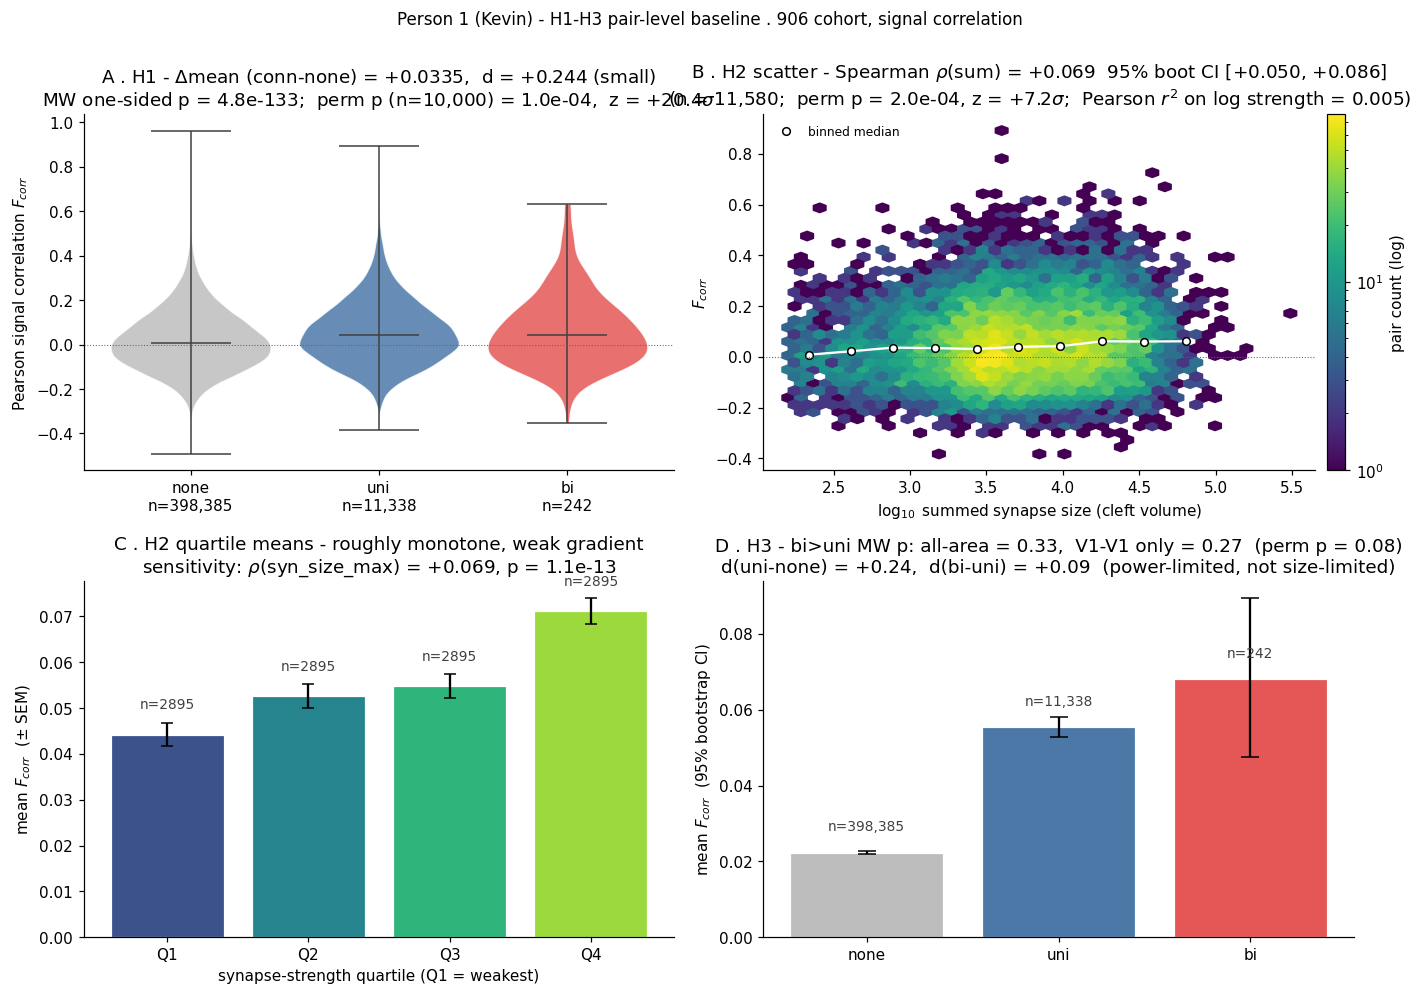

figure saved to: c:\Users\shaqi\Desktop\NeuroFinalProject\outputs\figures\person1_h1_h3_pair_baseline.png
table saved to : c:\Users\shaqi\Desktop\NeuroFinalProject\outputs\tables\person1_h1_h3_summary.csv

summary table (one row per hypothesis; NaN = column not applicable to that test):
hypothesis                             description                                 test_direction  n_connected  n_unconnected  mean_diff  median_diff    ci_lo    ci_hi  cohens_d  mannwhitney_U   p_one_sided  perm_n  perm_null_mean  perm_null_std    perm_z  perm_p_one_sided  spearman_rho_sum  spearman_ci_lo  spearman_ci_hi  p_spearman_sum  spearman_rho_max  p_spearman_max  pearson_log10_r  pearson_log10_r2  p_pearson_log10  perm_p_two_sided   n_none   n_uni  n_bi  mean_none  mean_uni  mean_bi  ci_lo_bi  ci_hi_bi  cohens_d_uni_vs_none  cohens_d_bi_vs_uni  p_uni_gt_none  p_bi_gt_none  p_bi_gt_uni  n_v1v1_none  n_v1v1_uni  n_v1v1_bi  mean_v1v1_none  mean_v1v1_uni  mean_v1v1_bi  p_v1v1_uni_gt_none  p_v1v1_bi

,hypothesis,description,test_direction,n_connected,n_unconnected,mean_diff,median_diff,ci_lo,ci_hi,cohens_d,...,p_v1v1_bi_gt_none,p_v1v1_bi_gt_uni,cohens_d_v1v1_uni_vs_none,cohens_d_v1v1_bi_vs_uni,perm_p_uni_gt_none,perm_p_bi_gt_none,perm_p_bi_gt_uni,perm_z_uni_gt_none,perm_z_bi_gt_none,perm_z_bi_gt_uni
0,H1,connected > unconnected (signal F_corr),one-sided (connected > unconnected),11580.0,398385.0,0.033459,0.032575,0.030857,0.036143,0.243701,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,H2,syn_size_sum vs F_corr (connected only),two-sided Spearman,11580.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,H3,reciprocity premium (bi > uni > none),one-sided pairwise (a > b for each comparison),NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.001668,0.265711,0.170387,0.087498,0.0002,0.0002,0.083183,20.275985,5.084478,1.412915


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# --- (A) H1: violin of f_corr by conn_type ---
ax = axes[0, 0]
data = [f_none, f_uni, f_bi]
parts = ax.violinplot(data, showmeans=False, showmedians=True, widths=0.85)
for k, body in enumerate(parts['bodies']):
    body.set_facecolor(PAL_CONN[ORDER_CONN[k]])
    body.set_edgecolor('white')
    body.set_alpha(0.85)
for key in ('cmedians', 'cbars', 'cmins', 'cmaxes'):
    parts[key].set_color('0.25')
    parts[key].set_linewidth(1.0)
ax.set_xticks([1, 2, 3])
ax.set_xticklabels([f'none\nn={len(f_none):,}',
                    f'uni\nn={len(f_uni):,}',
                    f'bi\nn={len(f_bi):,}'])
ax.set_ylabel(r'Pearson signal correlation $F_{corr}$')
ax.axhline(0, color='0.4', lw=0.7, ls=':')
ax.set_title(f'A . H1 - $\\Delta$mean (conn-none) = {md_h1:+.4f},  d = {d_h1:+.3f} (small)\n'
             f'MW one-sided p = {p_h1:.1e};  perm p (n={N_PERM:,}) = {p_perm:.1e},  z = {z_obs:+.1f}$\\sigma$')

# --- (B) H2 scatter: hexbin of log10 syn_size_sum vs f_corr (with binned-median overlay) ---
ax = axes[0, 1]
hb = ax.hexbin(conn['log10_size_sum'], conn['f_corr'],
               gridsize=40, mincnt=1, cmap='viridis', bins='log')
xb = np.linspace(conn['log10_size_sum'].min(), conn['log10_size_sum'].max(), 13)
ix = np.digitize(conn['log10_size_sum'].to_numpy(), xb)
xc, yb = [], []
for k in range(1, len(xb)):
    sel = (ix == k)
    if sel.sum() >= 20:
        xc.append(0.5 * (xb[k-1] + xb[k]))
        yb.append(np.median(conn['f_corr'].to_numpy()[sel]))
ax.plot(xc, yb, 'o-', color='white', mec='black', mfc='white', lw=1.5, ms=5,
        label='binned median')
ax.axhline(0, color='0.4', lw=0.7, ls=':')
ax.set_xlabel(r'$\log_{10}$ summed synapse size (cleft volume)')
ax.set_ylabel(r'$F_{corr}$')
ax.set_title(f'B . H2 scatter - Spearman $\\rho$(sum) = {rho_h2:+.3f}  '
             f'95% boot CI [{ci_lo_h2:+.3f}, {ci_hi_h2:+.3f}]\n'
             f'(n = {len(conn):,};  perm p = {p_perm_h2:.1e}, z = {z_obs_h2:+.1f}$\\sigma$;  '
             f'Pearson $r^2$ on log strength = {r2_log:.3f})')
ax.legend(loc='upper left', frameon=False, fontsize=8)
cb = plt.colorbar(hb, ax=ax, fraction=0.045, pad=0.02)
cb.set_label('pair count (log)')

# --- (C) H2 quartile means of f_corr ---
ax = axes[1, 0]
qx = np.arange(4)
ax.bar(qx, q['mean'], yerr=q['sem'],
       color=plt.cm.viridis(np.linspace(0.25, 0.85, 4)),
       edgecolor='white', linewidth=0.8, capsize=4)
for k, (mu, n_) in enumerate(zip(q['mean'], q['count'])):
    ax.text(k, mu + 0.005, f'n={n_}', ha='center', va='bottom', fontsize=9, color='0.25')
ax.set_xticks(qx); ax.set_xticklabels(q.index)
ax.set_ylabel(r'mean $F_{corr}$  ($\pm$ SEM)')
ax.set_xlabel('synapse-strength quartile (Q1 = weakest)')
ax.set_title(f'C . H2 quartile means - roughly monotone, weak gradient\n'
             f'sensitivity: $\\rho$(syn_size_max) = {rho_max:+.3f}, p = {p_rho_max:.1e}')

# --- (D) H3: mean +/- 95% CI by conn_type ---
ax = axes[1, 1]
xs = np.arange(3)
mu_  = [group_stats[g]['mean']  for g in ORDER_CONN]
los_ = [group_stats[g]['ci_lo'] for g in ORDER_CONN]
his_ = [group_stats[g]['ci_hi'] for g in ORDER_CONN]
err_lo = [m - lo for m, lo in zip(mu_, los_)]
err_hi = [hi - m for m, hi in zip(mu_, his_)]
ax.bar(xs, mu_, yerr=[err_lo, err_hi],
       color=[PAL_CONN[g] for g in ORDER_CONN],
       edgecolor='white', linewidth=0.8, capsize=6)
for k, g in enumerate(ORDER_CONN):
    ax.text(k, mu_[k] + 0.005, f'n={group_stats[g]["n"]:,}',
            ha='center', va='bottom', fontsize=9, color='0.25')
ax.set_xticks(xs); ax.set_xticklabels(ORDER_CONN)
ax.set_ylabel(r'mean $F_{corr}$  (95% bootstrap CI)')
ax.set_title(
    f'D . H3 - bi>uni MW p: all-area = {H3_RESULT["p_bi_gt_uni"]:.2f},  '
    f'V1-V1 only = {H3_RESULT["p_v1v1_bi_gt_uni"]:.2f}  '
    f'(perm p = {H3_RESULT["perm_p_bi_gt_uni"]:.2f})\n'
    f'd(uni-none) = {d_uni_none:+.2f},  d(bi-uni) = {d_bi_uni:+.2f}  '
    f'(power-limited, not size-limited)'
)

fig.suptitle('Person 1 (Kevin) - H1-H3 pair-level baseline . 906 cohort, signal correlation',
             y=1.00, fontsize=11)
fig.tight_layout()

fig_path = FIG_DIR / 'person1_h1_h3_pair_baseline.png'
fig.savefig(fig_path, bbox_inches='tight')
plt.show()
print(f'figure saved to: {fig_path}')

summary = pd.DataFrame([H1_RESULT, H2_RESULT, H3_RESULT])
tbl_path = TBL_DIR / 'person1_h1_h3_summary.csv'
summary.to_csv(tbl_path, index=False)
print(f'table saved to : {tbl_path}')
print()
print('summary table (one row per hypothesis; NaN = column not applicable to that test):')
with pd.option_context('display.max_columns', None, 'display.width', 220):
    print(summary.to_string(index=False))
summary

## 9. Interpretation grounded in this run

All numbers below are from the printed §5b / §6b / §7b cell outputs and from `outputs/tables/person1_h1_h3_summary.csv` (57 columns, three rows). Permutation-null `p`-values that hit the budget floor are reported as `≤ 1/(N_perm + 1)`; the corresponding z-score is the substantive number.

### H1 — connected vs unconnected

Connected pairs (n = 11,580) are more functionally similar than unconnected pairs (n = 398,385): Δmean F_corr = **+0.0335**, 95% bootstrap CI **[+0.0309, +0.0361]**, Cohen's *d* = **+0.244** (small). The naive Mann–Whitney `p ≈ 5 × 10⁻¹³³` massively overstates the evidence — pair rows are not independent because every neuron sits in N − 1 pairs. The right test is the **§5b neuron-identity permutation null** (10,000 permutations): the null Δmean distribution is centred at 0 with SD = 0.0016, and the observed Δmean sits at **z = +20.4σ**. No permutation in 10,000 produced a Δmean as large as observed, so perm-p ≤ **1 × 10⁻⁴** (the 1/10,001 floor) — best read as "effectively zero, bounded above by 10⁻⁴ from this sample size." **Connectedness shifts expected F_corr from +0.022 to +0.056** — a real but modest like-to-like signal, not a deterministic predictor.

A V1-only sensitivity check (printed in §7b) is reassuring but informative. Within V1 (n_none = 254,187, n_uni = 10,208) the connected-vs-unconnected effect is still highly significant (MW one-sided `p ≈ 9 × 10⁻⁵⁶`), but Cohen's *d* shrinks from **0.24 → 0.17**. The all-area effect was somewhat amplified by the lower mean F_corr of cross-area `none` pairs (V1↔RL/AL pairs run colder); the within-V1 *d* = 0.17 is the more conservative number to quote in the report.

### H2 — synapse-strength gradient (connected pairs)

Spearman ρ(`syn_size_sum`, F_corr) = **+0.0686**, 95% bootstrap CI [**+0.050, +0.086**]; using `syn_size_max` instead of `syn_size_sum` gives ρ = +0.069 — not a sum-vs-max artefact. The **proper variance-explained scale** is the Pearson r² on log₁₀-strength, which is **0.005**: log strength linearly explains under 1% of F_corr variance. Spearman ρ² is *not* a fraction of variance and is reported as a rank-correlation effect size only.

The naive Spearman `p ≈ 1.4 × 10⁻¹³` inherits the same pair-non-independence problem as H1's MW `p`. The **§6b neuron-identity permutation null** (5,000 permutations) gives the corrected number directly: the null distribution of ρ is centred at 0 with SD = 0.0095, and the observed ρ sits at **z = +7.2σ**. No permutation in 5,000 produced |ρ| ≥ 0.069, so two-sided perm-p ≤ **2 × 10⁻⁴** (floor). Quartile means rise from Q1 (+0.044) through Q4 (+0.071), consistent with the Spearman estimate; we report this as a **roughly monotone, weak gradient** without reading shape into individual quartile steps. Consistent with prior MICrONS work, the like-to-like rule is largely a *binary* connection effect, with only weak graded modulation by synaptic strength.

### H3 — reciprocity premium

Group means rank as predicted: none = +0.022, uni = +0.055, bi = +0.068 (n_bi = 242). Three things to read from this section:

1. **uni > none and bi > none are robust.** All-area MW: `uni > none` `p ≈ 6 × 10⁻¹³⁰`, `bi > none` `p ≈ 5 × 10⁻⁵`. §7b permutation null: `uni − none` z = **+20.3σ**, `bi − none` z = **+5.1σ**, both with perm-p ≤ 2 × 10⁻⁴ (floor). Connectedness *does* add a detectable functional-similarity signal in either reading.

2. **bi > uni is not significant under any test.** All-area MW: `p = 0.33`. §7b permutation null: `bi − uni` z = **+1.4σ, perm-p = 0.083** — note this perm-p is tighter than the MW p (0.33) because the permutation null reflects the actual between-group difference distribution rather than the rank distribution, but it still does not cross 0.05. V1-V1-stratified MW: `p = 0.27`.

3. **The area-composition concern was a reasonable design check, but it did not drive an artefactual difference.** §7 showed `bi` pairs are 96.3% V1-V1 (233/242) versus 90.0% V1-V1 for `uni` (10,208/11,338), which in principle could inflate the all-area `bi` mean relative to `uni`. The §7b V1-V1-stratified test evaluates this directly: bi mean = 0.0667, uni mean = 0.0542, **gap = 0.0125 — essentially identical to the all-area gap of 0.0126**. Cohen's *d* for `bi − uni` is +0.087 in both samples. The bi vs uni near-tie is not an area-composition artefact; it is a real (small) effect that the cohort lacks the power to resolve.

The cleanest power-aware framing: with n_bi = 242 the design has good power for an effect the size of `uni − none` (Cohen's *d* ≈ 0.24 all-area, 0.17 within V1) but only modest power for the *observed* `bi − uni` gap (*d* ≈ 0.09 in either sample). The data therefore **exclude a `bi − uni` gap as large as the `uni − none` step** while not ruling out a small positive `bi − uni` effect. **Reciprocity does not add a detectable premium on top of connectedness in this cohort**, and this conclusion is robust to area-stratification and to pair-non-independence corrections.

### Report-ready summary paragraph

In the 906-neuron MICrONS cohort, **structurally connected neuron pairs are more functionally similar than unconnected pairs** (Δmean signal correlation = +0.033, 95% CI [+0.031, +0.036], Cohen's *d* = 0.24; a 10,000-permutation neuron-identity null places the observation at z = +20.4σ above its mean, perm-p ≤ 10⁻⁴). The effect is robust to V1-only stratification (within-V1 *d* = 0.17, MW p ≈ 9 × 10⁻⁵⁶) and is therefore not an artefact of area heterogeneity. Among connected pairs, **larger summed synaptic strength predicts slightly higher functional correlation** (Spearman ρ = +0.069, 95% bootstrap CI [+0.050, +0.086]; Pearson r² on log strength = 0.005; permutation null places the observed ρ at z = +7.2σ, perm-p ≤ 2 × 10⁻⁴), with the gradient roughly monotone across synapse-strength quartiles. Reciprocal connections show the highest mean correlation, but only **uni > none** and **bi > none** are statistically supported under both Mann–Whitney and permutation tests; the **bi > uni** difference is not significant under any test (all-area MW p = 0.33, V1-V1-stratified MW p = 0.27, permutation p = 0.083). The V1-V1 stratification confirms that the small bi-uni gap is not driven by area composition, and the design rules out a reciprocity effect as large as the connectedness effect itself. Together, the results describe a **statistically robust but quantitatively modest** like-to-like wiring rule: anatomy carries detectable functional information, but does not determine functional similarity between individual neurons, and reciprocity does not add a detectable premium on top of connectedness in this cohort.